# 06 — Скоринг сегментов для периодов недозаселения

## Цель ноутбука

Для каждой даты из списка недозаселения нам нужно **ранжировать все 6 сегментов** и выбрать наиболее перспективный для маркетингового воздействия.

## Как работает скоринг?

Для каждой пары (дата, сегмент) вычисляется итоговый **score** — взвешенная сумма нескольких компонентов:

| Компонент | Вес | Смысл |
|-----------|-----|-------|
| `season_score` | 0.35 | Насколько сегмент исторически активен в данный сезон |
| `value_score` | 0.25 | Средний "ценовой tier" сегмента — прокси для выручки |
| `stability_score` | 0.20 | Обратная доля скидок (устойчивость без акций) |
| `lead_score` | 0.20 | Горизонт планирования — успеем ли запустить акцию |

**Итого**: сумма весов = 1.0, каждый компонент нормирован в [0, 1].

## Почему именно эти компоненты?

- **season_score**: нет смысла рекламировать зимний сегмент летом — affinity matrix даёт чёткий сигнал
- **value_score**: маркетинг хочет максимизировать выручку, поэтому ULTRA-сегмент ценнее LIGHT
- **stability_score**: сегмент, который и так бронирует без скидок — лучший кандидат для органической кампании
- **lead_score**: сегмент с длинным `lead_time` планирует заранее → нужно запускать акцию раньше

## Входные данные
- `ml/forecasting/artifacts_forecasting/underload_dates.parquet`
- `artifacts_recommender/segment_history.parquet`
- `artifacts_recommender/season_affinity.parquet`

## Выходные артефакты
- `artifacts_recommender/segment_scores.parquet` — score по всем (дата, сегмент)

## 1. Импорты и загрузка

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

warnings.filterwarnings('ignore')

FORECAST_DIR = Path('..') / 'forecasting' / 'artifacts_forecasting'
OUT_DIR      = Path('artifacts_recommender')

# Загружаем данные о проблемных датах
df_underload = pd.read_parquet(FORECAST_DIR / 'underload_dates.parquet')
df_underload['ds'] = pd.to_datetime(df_underload['ds'])

# Загружаем метрики сегментов
df_seg_hist = pd.read_parquet(OUT_DIR / 'segment_history.parquet')

# Загружаем матрицу сезонной affinity
season_affinity = pd.read_parquet(OUT_DIR / 'season_affinity.parquet')

SEGMENT_NAMES = {
    0: 'Summer Family ULTRA',
    1: 'Weekend Getaway',
    2: 'Weekday Adults',
    3: 'Last-minute Winter',
    4: 'Young Spring Groups',
    5: 'Medical Treatment'
}

print(f'Проблемных дат: {len(df_underload):,}')
print(f'Сегментов: {len(df_seg_hist)}')
print(f'Affinity matrix: {season_affinity.shape}')
print('\nAffinity matrix:')
print(season_affinity.round(3))

C:\Users\sp1ts\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Проблемных дат: 160
Сегментов: 6
Affinity matrix: (6, 4)

Affinity matrix:
season      winter  spring  summer  autumn
cluster_v4                                
0            0.134   0.219   0.484   0.162
1            0.256   0.318   0.216   0.210
2            0.148   0.236   0.345   0.270
3            0.336   0.308   0.158   0.197
4            0.294   0.354   0.184   0.168
5            0.072   0.183   0.427   0.317


## 2. Нормализация признаков для скоринга

Чтобы сложить разные метрики с разными шкалами, нормализуем каждый компонент в диапазон [0, 1].  
Используем min-max нормализацию:
```
x_norm = (x - x_min) / (x_max - x_min)
```

In [2]:
def minmax_normalize(series: pd.Series) -> pd.Series:
    """
    Нормализует Series в диапазон [0, 1].
    Если все значения одинаковые — возвращает 0.5 для всех.
    """
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5] * len(series), index=series.index)
    return (series - mn) / (mx - mn)

# --- season_score: нормализуем affinity внутри каждого сезона между сегментами ---
# Сырые значения season_affinity — это доли сезона внутри сегмента, строки суммируются в 1.
# Для выбора сегмента на конкретную дату нам нужна относительная пригодность сегментов в этом сезоне.
season_score_matrix = season_affinity.apply(minmax_normalize, axis=0).round(4)

# --- value_score: нормализованный avg_price_tier ---
# Чем выше price_tier — тем выше ценность сегмента
if 'avg_price_tier' in df_seg_hist.columns:
    df_seg_hist['value_score'] = minmax_normalize(df_seg_hist['avg_price_tier'])
else:
    # Если нет price_tier — используем долю лечебных (is_treatment)
    df_seg_hist['value_score'] = minmax_normalize(df_seg_hist.get('pct_treatment', pd.Series([0.5]*6, index=df_seg_hist.index)))

# --- stability_score: обратная доля скидок ---
# Сегмент, который бронирует редко по скидке, стабильнее платит полную цену
if 'pct_with_discount' in df_seg_hist.columns:
    df_seg_hist['stability_score'] = minmax_normalize(1 - df_seg_hist['pct_with_discount'])
else:
    df_seg_hist['stability_score'] = 0.5  # нейтральное значение если нет данных

# --- lead_score: нормализованный средний lead_time ---
# Высокий lead_time = сегмент планирует заранее = маркетинг успеет его зацепить
if 'avg_lead_time_log' in df_seg_hist.columns:
    df_seg_hist['lead_score'] = minmax_normalize(df_seg_hist['avg_lead_time_log'])
else:
    df_seg_hist['lead_score'] = 0.5

print('Компоненты скора по сегментам:')
score_cols = [c for c in ['value_score', 'stability_score', 'lead_score'] if c in df_seg_hist.columns]
display_df = df_seg_hist[['segment_name'] + score_cols].round(3)
print(display_df.to_string(index=True))

Компоненты скора по сегментам:
                   segment_name  value_score  stability_score  lead_score
cluster_v4                                                               
0           Summer Family ULTRA        1.000            0.000       1.000
1               Weekend Getaway        0.585            0.775       0.640
2                Weekday Adults        0.963            0.648       0.927
3            Last-minute Winter        0.991            0.254       0.000
4           Young Spring Groups        0.000            1.000       0.605
5             Medical Treatment        0.956            0.514       0.976


## 3. Функция скоринга

Основная логика: для каждой (дата, сегмент) вычисляем итоговый score.  
Season_score зависит от конкретной даты → вычисляется динамически.  
Остальные компоненты — статические свойства сегмента.

In [3]:
# Веса компонентов скоринга (сумма = 1.0)
WEIGHTS = {
    'season_score':    0.50,   # важнейший — сезонное совпадение
    'value_score':     0.20,   # ценность сегмента (price tier)
    'stability_score': 0.15,   # устойчивость без скидок
    'lead_score':      0.15,   # горизонт планирования
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-6, "Сумма весов должна быть 1.0!"
print(f'Веса: {WEIGHTS}')
print(f'Сумма весов: {sum(WEIGHTS.values())}')


def compute_segment_score(cluster_id: int, season: str) -> float:
    """
    Вычисляет итоговый score сегмента для конкретного сезона.

    Параметры
    ----------
    cluster_id : int — номер кластера (0-5)
    season     : str — сезон ('winter'/'spring'/'summer'/'autumn')

    Возвращает
    ----------
    float — итоговый score в [0, 1]
    """
    seg = df_seg_hist.loc[cluster_id]

    # Динамический компонент: affinity к текущему сезону
    season_score = season_score_matrix.loc[cluster_id, season] if season in season_score_matrix.columns else 0.5

    # Статические компоненты из паспорта сегмента
    value_score     = float(seg.get('value_score', 0.5))
    stability_score = float(seg.get('stability_score', 0.5))
    lead_score      = float(seg.get('lead_score', 0.5))

    # Взвешенная сумма
    total = (
        WEIGHTS['season_score']    * season_score    +
        WEIGHTS['value_score']     * value_score     +
        WEIGHTS['stability_score'] * stability_score +
        WEIGHTS['lead_score']      * lead_score
    )
    return round(total, 4)


# Тест: проверяем скоры для каждого сегмента по сезонам
print('\nТест скоринга — лето (ожидаем C0 и C5 наверху):')
summer_scores = {cid: compute_segment_score(cid, 'summer') for cid in range(6)}
for cid, score in sorted(summer_scores.items(), key=lambda x: -x[1]):
    print(f'  C{cid} {SEGMENT_NAMES[cid]:25s}: {score:.4f}')

print('\nТест скоринга — зима (ожидаем C3 наверху):')
winter_scores = {cid: compute_segment_score(cid, 'winter') for cid in range(6)}
for cid, score in sorted(winter_scores.items(), key=lambda x: -x[1]):
    print(f'  C{cid} {SEGMENT_NAMES[cid]:25s}: {score:.4f}')

Веса: {'season_score': 0.5, 'value_score': 0.2, 'stability_score': 0.15, 'lead_score': 0.15}
Сумма весов: 1.0

Тест скоринга — лето (ожидаем C0 и C5 наверху):
  C0 Summer Family ULTRA      : 0.8500
  C5 Medical Treatment        : 0.8273
  C2 Weekday Adults           : 0.7157
  C1 Weekend Getaway          : 0.4180
  C4 Young Spring Groups      : 0.2807
  C3 Last-minute Winter       : 0.2363

Тест скоринга — зима (ожидаем C3 наверху):
  C3 Last-minute Winter       : 0.7363
  C1 Weekend Getaway          : 0.6776
  C4 Young Spring Groups      : 0.6612
  C2 Weekday Adults           : 0.5728
  C0 Summer Family ULTRA      : 0.4674
  C5 Medical Treatment        : 0.4147


## 4. Вычисление скоров для всех проблемных дат

Для каждой даты из `underload_dates` применяем `compute_segment_score` по всем 6 сегментам.  
Результат — декартово произведение (дата × сегмент) с итоговым score.

In [4]:
print(f'Вычисляем скоры для {len(df_underload):,} дат × 6 сегментов...')

records = []
for _, date_row in df_underload.iterrows():
    season = date_row['season']

    # Скорим все 6 сегментов для этой даты
    for cluster_id in range(6):
        score = compute_segment_score(cluster_id, season)

        # Разбиваем score на компоненты для интерпретации
        seg = df_seg_hist.loc[cluster_id]
        season_s = season_score_matrix.loc[cluster_id, season] if season in season_score_matrix.columns else 0.5

        records.append({
            'ds':               date_row['ds'],
            'cluster_v4':       cluster_id,
            'segment_name':     SEGMENT_NAMES[cluster_id],
            'season':           season,
            'yhat':             date_row['yhat'],
            'load_gap':         date_row['load_gap_global'],
            'underload_pct':    date_row['underload_pct'],
            'score':            score,
            'score_season':     round(season_s, 4),
            'score_value':      round(float(seg.get('value_score', 0.5)), 4),
            'score_stability':  round(float(seg.get('stability_score', 0.5)), 4),
            'score_lead':       round(float(seg.get('lead_score', 0.5)), 4),
        })

df_scores = pd.DataFrame(records)
print(f'Готово! Строк в матрице скоров: {len(df_scores):,}')
df_scores.head(12)

Вычисляем скоры для 160 дат × 6 сегментов...


Готово! Строк в матрице скоров: 960

,ds,cluster_v4,segment_name,season,yhat,load_gap,underload_pct,score,score_season,score_value,score_stability,score_lead
0,2025-10-31,0,Summer Family ULTRA,autumn,293.181837,55.8,46.3,0.3500,0.0000,1.0000,0.0000,1.0000
1,2025-10-31,1,Weekend Getaway,autumn,293.181837,55.8,46.3,0.4839,0.3097,0.5846,0.7746,0.6397
2,2025-10-31,2,Weekday Adults,autumn,293.181837,55.8,46.3,0.7773,0.6968,0.9635,0.6479,0.9268
3,2025-10-31,3,Last-minute Winter,autumn,293.181837,55.8,46.3,0.3492,0.2258,0.9913,0.2535,0.0000
4,2025-10-31,4,Young Spring Groups,autumn,293.181837,55.8,46.3,0.2601,0.0387,0.0000,1.0000,0.6051
5,2025-10-31,5,Medical Treatment,autumn,293.181837,55.8,46.3,0.9147,1.0000,0.9558,0.5141,0.9763
6,2025-11-01,0,Summer Family ULTRA,autumn,291.080857,57.9,46.7,0.3500,0.0000,1.0000,0.0000,1.0000
7,2025-11-01,1,Weekend Getaway,autumn,291.080857,57.9,46.7,0.4839,0.3097,0.5846,0.7746,0.6397
8,2025-11-01,2,Weekday Adults,autumn,291.080857,57.9,46.7,0.7773,0.6968,0.9635,0.6479,0.9268
9,2025-11-01,3,Last-minute Winter,autumn,291.080857,57.9,46.7,0.3492,0.2258,0.9913,0.2535,0.0000


## 5. Ранжирование: топ-3 сегмента на каждую дату

In [5]:
# Ранжируем внутри каждой даты по убыванию score
df_scores['rank'] = (
    df_scores
    .groupby('ds')['score']
    .rank(ascending=False, method='first')
    .astype(int)
)

# Статистика: как часто каждый сегмент попадает в топ-1
top1_dist = df_scores[df_scores['rank'] == 1]['cluster_v4'].value_counts()
print('Распределение по top-1 рекомендациям (сколько раз каждый сегмент рекомендован первым):')
for cid, cnt in top1_dist.items():
    print(f'  C{cid} {SEGMENT_NAMES[cid]:25s}: {cnt} дней ({cnt/len(df_underload):.1%})')

# Проверка: для зимних дат должен лидировать C3
winter_top1 = df_scores[(df_scores['rank'] == 1) & (df_scores['season'] == 'winter')]['cluster_v4'].value_counts()
print('\nTop-1 для зимних дат:')
print(winter_top1)

Распределение по top-1 рекомендациям (сколько раз каждый сегмент рекомендован первым):
  C3 Last-minute Winter       : 80 дней (50.0%)
  C5 Medical Treatment        : 47 дней (29.4%)
  C4 Young Spring Groups      : 29 дней (18.1%)
  C0 Summer Family ULTRA      : 4 дней (2.5%)

Top-1 для зимних дат:
cluster_v4
3    80
Name: count, dtype: int64


## 6. Визуализация скоров

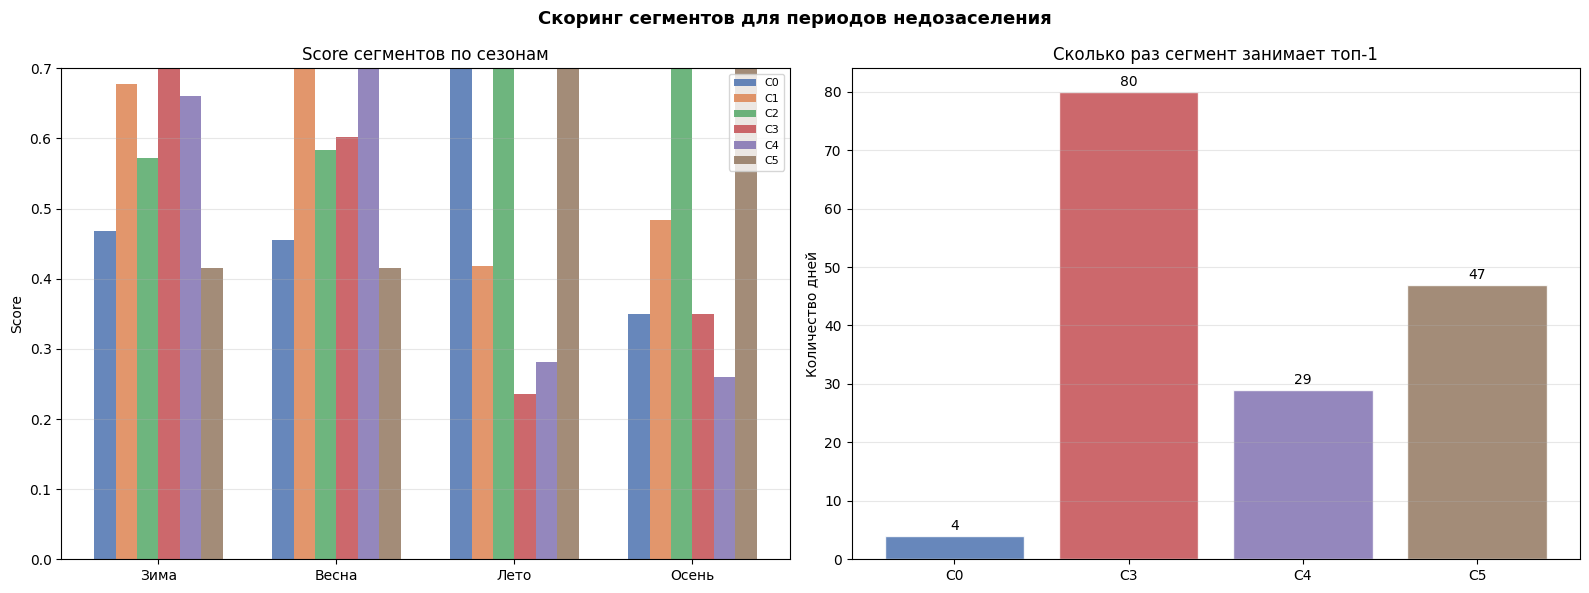

График сохранён: artifacts_recommender/segment_scoring.png


In [6]:
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Скоринг сегментов для периодов недозаселения', fontsize=13, fontweight='bold')

# ── График 1: Средний score по сезонам ───────────────────────────────────────
ax1 = axes[0]
seasons = ['winter', 'spring', 'summer', 'autumn']
x = np.arange(len(seasons))
width = 0.12

for i in range(6):
    seg_scores = [compute_segment_score(i, s) for s in seasons]
    ax1.bar(x + i * width, seg_scores, width, label=f'C{i}', color=COLORS[i], alpha=0.85)

ax1.set_xticks(x + 2.5 * width)
ax1.set_xticklabels(['Зима', 'Весна', 'Лето', 'Осень'])
ax1.set_ylabel('Score')
ax1.set_title('Score сегментов по сезонам')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 0.7)

# ── График 2: Частота попадания в топ-1 ───────────────────────────────────────
ax2 = axes[1]
top1_all = df_scores[df_scores['rank'] == 1]['cluster_v4'].value_counts().sort_index()
bars = ax2.bar(
    [f'C{i}' for i in top1_all.index],
    top1_all.values,
    color=[COLORS[i] for i in top1_all.index],
    alpha=0.85, edgecolor='white'
)
ax2.set_ylabel('Количество дней')
ax2.set_title('Сколько раз сегмент занимает топ-1')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, top1_all.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / 'segment_scoring.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: artifacts_recommender/segment_scoring.png')

## 7. Сохранение матрицы скоров

In [7]:
df_scores.to_parquet(OUT_DIR / 'segment_scores.parquet', index=False)
print(f'Сохранено: segment_scores.parquet — {len(df_scores):,} строк')
print(f'Колонки: {list(df_scores.columns)}')
print('\nГотово! Следующий шаг → 07_recommendations.ipynb')

Сохранено: segment_scores.parquet — 960 строк
Колонки: ['ds', 'cluster_v4', 'segment_name', 'season', 'yhat', 'load_gap', 'underload_pct', 'score', 'score_season', 'score_value', 'score_stability', 'score_lead', 'rank']

Готово! Следующий шаг → 07_recommendations.ipynb


<!-- FINAL_CAPACITY_AWARE_BLOCK -->

## Final block: capacity-aware segment scoring

Recomputes segment scores from the updated underload_dates.parquet so gap and risk dates match the capacity-aware method.

In [8]:
from pathlib import Path
import pandas as pd

if Path('artifacts_recommender').exists():
    OUT_DIR = Path('artifacts_recommender')
    FORECAST_DIR = Path('..') / 'forecasting' / 'artifacts_forecasting'
elif Path('recommender/artifacts_recommender').exists():
    OUT_DIR = Path('recommender') / 'artifacts_recommender'
    FORECAST_DIR = Path('forecasting') / 'artifacts_forecasting'
else:
    raise FileNotFoundError('artifacts_recommender and artifacts_forecasting were not found. Run the notebook from ml/ or ml/recommender/.')

SEGMENT_NAMES_FALLBACK = {
    0: 'Summer Family ULTRA',
    1: 'Weekend Getaway',
    2: 'Weekday Adults',
    3: 'Last-minute Winter',
    4: 'Young Spring Groups',
    5: 'Medical Treatment',
}
WEIGHTS_FINAL = {
    'season_score': 0.50,
    'value_score': 0.20,
    'stability_score': 0.15,
    'lead_score': 0.15,
}

def minmax_normalize_final(series: pd.Series) -> pd.Series:
    min_value = series.min()
    max_value = series.max()
    if max_value == min_value:
        return pd.Series(0.5, index=series.index)
    return (series - min_value) / (max_value - min_value)

df_underload = pd.read_parquet(FORECAST_DIR / 'underload_dates.parquet')
df_underload['ds'] = pd.to_datetime(df_underload['ds'])
df_seg_hist = pd.read_parquet(OUT_DIR / 'segment_history.parquet')
season_affinity = pd.read_parquet(OUT_DIR / 'season_affinity.parquet')

segment_names = globals().get('SEGMENT_NAMES', SEGMENT_NAMES_FALLBACK)
season_score_matrix = season_affinity.apply(minmax_normalize_final, axis=0).round(4)
hist = df_seg_hist.copy()
hist['value_score'] = minmax_normalize_final(hist['avg_price_tier'])
hist['stability_score'] = minmax_normalize_final(1 - hist['pct_with_discount'])
hist['lead_score'] = minmax_normalize_final(hist['avg_lead_time_log'])

records = []
for _, date_row in df_underload.iterrows():
    season = date_row['season']
    for cluster_id in sorted(hist.index.astype(int)):
        seg = hist.loc[cluster_id]
        season_score = float(season_score_matrix.loc[cluster_id, season])
        score = round(
            WEIGHTS_FINAL['season_score'] * season_score
            + WEIGHTS_FINAL['value_score'] * float(seg['value_score'])
            + WEIGHTS_FINAL['stability_score'] * float(seg['stability_score'])
            + WEIGHTS_FINAL['lead_score'] * float(seg['lead_score']),
            4,
        )
        records.append({
            'ds': date_row['ds'],
            'cluster_v4': cluster_id,
            'segment_name': segment_names.get(cluster_id, f'C{cluster_id}'),
            'season': season,
            'yhat': date_row['yhat'],
            'load_gap': date_row.get('load_gap_season', date_row.get('load_gap_global')),
            'underload_pct': date_row['underload_pct'],
            'score': score,
            'score_season': round(season_score, 4),
            'score_value': round(float(seg['value_score']), 4),
            'score_stability': round(float(seg['stability_score']), 4),
            'score_lead': round(float(seg['lead_score']), 4),
        })

df_scores = pd.DataFrame(records)
df_scores['rank'] = df_scores.groupby('ds')['score'].rank(ascending=False, method='first').astype(int)
df_scores.to_parquet(OUT_DIR / 'segment_scores.parquet', index=False)

print('??????? ?????????? ?? capacity-aware underload_dates.parquet.')
print(f'?????????: segment_scores.parquet ? {len(df_scores):,} ?????')
display(df_scores.sort_values(['ds', 'rank']).head(12))


??????? ?????????? ?? capacity-aware underload_dates.parquet.
?????????: segment_scores.parquet ? 960 ?????


,ds,cluster_v4,segment_name,season,yhat,load_gap,underload_pct,score,score_season,score_value,score_stability,score_lead,rank
5,2025-10-31,5,Medical Treatment,autumn,293.181837,252.6,46.3,0.9147,1.0000,0.9558,0.5141,0.9763,1
2,2025-10-31,2,Weekday Adults,autumn,293.181837,252.6,46.3,0.7773,0.6968,0.9635,0.6479,0.9268,2
1,2025-10-31,1,Weekend Getaway,autumn,293.181837,252.6,46.3,0.4839,0.3097,0.5846,0.7746,0.6397,3
0,2025-10-31,0,Summer Family ULTRA,autumn,293.181837,252.6,46.3,0.3500,0.0000,1.0000,0.0000,1.0000,4
3,2025-10-31,3,Last-minute Winter,autumn,293.181837,252.6,46.3,0.3492,0.2258,0.9913,0.2535,0.0000,5
4,2025-10-31,4,Young Spring Groups,autumn,293.181837,252.6,46.3,0.2601,0.0387,0.0000,1.0000,0.6051,6
11,2025-11-01,5,Medical Treatment,autumn,291.080857,254.7,46.7,0.9147,1.0000,0.9558,0.5141,0.9763,1
8,2025-11-01,2,Weekday Adults,autumn,291.080857,254.7,46.7,0.7773,0.6968,0.9635,0.6479,0.9268,2
7,2025-11-01,1,Weekend Getaway,autumn,291.080857,254.7,46.7,0.4839,0.3097,0.5846,0.7746,0.6397,3
6,2025-11-01,0,Summer Family ULTRA,autumn,291.080857,254.7,46.7,0.3500,0.0000,1.0000,0.0000,1.0000,4
